SETUP OR FETCH OUR ENVIRONMENT VARIABLES 

In [ ]:
import os
# Groq (model provider)
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

#search API Keys
os.environ['TAVILY_API_KEY']= os.getenv("TAVILY_API_KEY")
os.environ['SERPER_API_KEY']= os.getenv("SERPER_API_KEY")

print("Keys Set!")

Keys Set


In [4]:
from langchain.chat_models import init_chat_model


#Use Groq LLM

model = init_chat_model(
    model="groq:llama-3.3-70b-versatile",
    temperature=0.3
)

print("LLM Initialized: ", model)

LLM Initialized:  profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x000001B8B1184D70> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B8B1185400> model_name='llama-3.3-70b-versatile' temperature=0.3 model_kwargs={} groq_api_key=SecretStr('**********')


SEARCH FUNCTIONALITY


In [5]:
from langchain_tavily import TavilySearch

tavily_search= TavilySearch(
    max_results=5,
    topic="general"
)

print("Tavily Search Tool is ready")

Tavily Search Tool is ready


In [6]:
from langchain_community.utilities import GoogleSerperAPIWrapper

google_search= GoogleSerperAPIWrapper(

)

print("Google Serper wrapper ready")

Google Serper wrapper ready


Test Google Serper

In [7]:
result= google_search.run("Best places to visit in Hyderabad travle guide")
print(result)

Many of the top things to do in Hyderabad involve visits to architectural masterpieces—the elegant Chowmahalla Palace and the landmark Charminar ... Some of the popular of these family attractions are Ramoji Film city, Durgam Cheruvu, Public Gardens, Nehru Zoological Park, Necklace Road, Snow ... Hyderabad Travel Guide 2025 | Best Tourist Places, Food, and Travel Tips Planning a trip to Hyderabad in 2025? This ultimate Hyderabad ... A narrative guide to places to visit in Hyderabad in 3 days. Get to know the historical monuments but also where to escape from the heat, ... Charminar · Golconda fort · Qutb shahi tombs · Necklace road · Ramoji Film City · Durgam cheruvu bridge · Shilparamam · Zoological park ... Best things to do in Hyderabad · #1 Explore the Salar Jung Museum · #2 See the four minarets of Charminar · #3 Be wowed by Chowmahalla Palace · #4 Take in bustling ... From unknown monuments of the Nizam's era and one-of-a-kind ice cream parlours to inspiring stories of overcoming

In [ ]:
tavily_search.invoke({"query": "give me the latest news of Hyderabad"})


In [9]:
def tavily_search_tool(query: str) -> str:
    """
    Search the web using Travily for travel info,tips,attractions,etc.
    """
    # Call the existing TavilySearch tool underneath
    return tavily_search.invoke({"query": query})
def google_serper_search_tool(query: str) -> str:
    """
    Search the web using Google Serper for up-to-date travle info.
    """

    return google_search.run(query)

In [ ]:
tavily_search_tool("plan a trip to India")

In [11]:
google_serper_search_tool("Plan a trip to India")

"A Beginner's Guide to Planning a Trip to India · Day 1: Dive into Delhi · Day 2: Delhi in full color · Day 3: Road to Agra · Day 4: Taj Mahal ... This India for beginners guide breaks down India trip planning, my top 5 fave trip routes in India and costs and prices in India. India Vacations & Trips from $837 · 1. Create memories in Delhi with a vacation package · 2. Explore New Delhi with a vacation package · 3. Enjoy Mumbai with a ... Explore India itineraries from 7–14 days. Get inspired and customize your trip with Rough Guides' local experts for stress-free travel. Start planning your India vacation in 2026 or 2027 with an Audley specialist, who'll design your trip using first-hand knowledge. 1. Slow down · 2. Adjust your attitude · 3. Be careful who you trust · 4. Practice safe travel · 5. Try a small group tour · 6. Take the train · 7. If you do plan to venture over to India, here's some practical tips to help you pack, plan and know what to expect when you arrive. Our key piece

In [12]:
from langchain.agents import create_agent

system_prompt= """
You are a travle planner assistant. User asks travel queries like 
'plan my trip to X', 'what to do in Y hotel',etc.
Always use the avaliable web search tools (TavilySearch,GoogleSerperSearch)
to look up latest real-world travel info. Provide a helpful and clear itinerary/answers
"""

Travle planner agent is ready!


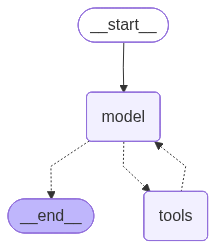

In [14]:
agent= create_agent(
    model=model,
    tools=[tavily_search_tool,google_serper_search_tool],
    system_prompt=system_prompt.strip()
)

print("Travle planner agent is ready!")
agent

In [15]:
response=agent.invoke({
    "messages": [
        {"role": "user","content": "Give me a 3 day plan for India travle with places to see"}
    ]
})
print("Agent answer is: \n")
print(response)

Agent answer is: 

{'messages': [HumanMessage(content='Give me a 3 day plan for India travle with places to see', additional_kwargs={}, response_metadata={}, id='4e75e6dc-230e-4d37-a7b5-e75203c6dd09'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6n3v6djdy', 'function': {'arguments': '{"query":"3 day India travel itinerary"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': '23wc0ab0e', 'function': {'arguments': '{"query":"India travel guide"}', 'name': 'google_serper_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 393, 'total_tokens': 433, 'completion_time': 0.126100528, 'completion_tokens_details': None, 'prompt_time': 0.040150846, 'prompt_tokens_details': None, 'queue_time': 0.049613763, 'total_time': 0.166251374}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider':

In [ ]:
print(response["messages"])


[HumanMessage(content='Give me a 3 day plan for India travle with places to see', additional_kwargs={}, response_metadata={}, id='4e75e6dc-230e-4d37-a7b5-e75203c6dd09'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6n3v6djdy', 'function': {'arguments': '{"query":"3 day India travel itinerary"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': '23wc0ab0e', 'function': {'arguments': '{"query":"India travel guide"}', 'name': 'google_serper_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 393, 'total_tokens': 433, 'completion_time': 0.126100528, 'completion_tokens_details': None, 'prompt_time': 0.040150846, 'prompt_tokens_details': None, 'queue_time': 0.049613763, 'total_time': 0.166251374}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d14c4-d

In [18]:
final_answer= response["messages"][-1].content

print(final_answer)

Here's a 3-day plan for India travel with places to see:

Day 1: Delhi Exploration
- Start early in Delhi to explore both the old and new sections of the city.
- Visit Raj Ghat, Chandni Chowk, Jama Masjid, the Red Fort, Qutub Minar, and Humayun's Tomb.

Day 2: Agra and the Taj Mahal
- Leave Delhi early for the 4-hour drive to Agra.
- Explore the Taj Mahal, Agra Fort, and Fatehpur Sikri.

Day 3: Jaipur
- Drive to Jaipur (5 hours) and explore the city.
- Visit Amber Fort, Hawa Mahal, and the City Palace.

This itinerary provides a mix of cultural, historical, and architectural experiences, and is a great starting point for your trip to India.
